# Carmine — engine and benchmarks

Carmine is a virtual makeup engine. It paints lipstick, eyeshadow, eyeliner,
brows, blush and highlighter onto a face while keeping the skin's own texture
and lighting, instead of flattening the region into a sticker of flat colour.

It ships as two surfaces over one algorithm:

* a **Python engine and CLI** for stills and video files, and
* a **browser mirror** (WebGL2 + wasm landmarks) that runs the same pipeline
  on a live camera feed, entirely on the viewer's device.

This notebook is the engineering write-up. It does three things:

1. demonstrates the pipeline end to end on a public-domain portrait,
2. explains how the evaluation was designed — including a scoring protocol
   that was tried and thrown away, and
3. republishes every measured claim with its protocol and its caveats.

**It never re-runs a benchmark.** The measurements live in
`reports/benchmark.json` (photo quality + video stability) and
`reports/browser_metrics.json` (cross-surface parity + per-stage timing), are
produced by the scripts in `scripts/`, and are committed. Every cell below
that narrates a number asserts that number against those files, so if the
measurements change and the prose does not, this notebook stops executing.

In [1]:
import json
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 80, "savefig.dpi": 80, "font.family": "sans-serif"})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

# Use the model bundled with the web app, so this notebook needs no network
# and always runs against the same checksum-pinned weights the site ships.
os.environ.setdefault(
    "CARMINE_MODEL", str(ROOT / "web" / "public" / "models" / "face_landmarker.task")
)

BENCH = json.loads((ROOT / "reports" / "benchmark.json").read_text())
BROWSER = json.loads((ROOT / "reports" / "browser_metrics.json").read_text())

PHOTO = {row["method"]: row for row in BENCH["photo"]["rows"]}
META = BENCH["meta"]
STABILITY = BENCH["stability"]


def close(value, expected, tol):
    """Assert a narrated number matches its source, and hand it back."""
    assert abs(value - expected) <= tol, f"{value} is not within {tol} of {expected}"
    return value


def table(headers, rows, aligns=None):
    """Print a small fixed-width table (no dataframe dependency)."""
    aligns = aligns or [">"] * len(headers)
    aligns[0] = "<"
    cells = [[str(c) for c in row] for row in rows]
    widths = [max(len(h), *(len(r[i]) for r in cells)) for i, h in enumerate(headers)]
    line = "  ".join(f"{h:{'<' if i == 0 else '>'}{widths[i]}}" for i, h in enumerate(headers))
    print(line)
    print("  ".join("-" * w for w in widths))
    for row in cells:
        print("  ".join(f"{c:{aligns[i]}{widths[i]}}" for i, c in enumerate(row)))


def show(images, titles, height=320, width_per=3.0, suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=(width_per * len(images), 3.4))
    axes = np.atleast_1d(axes)
    for ax, img, title in zip(axes, images, titles):
        h, w = img.shape[:2]
        tile = cv2.resize(img, (int(w * height / h), height))
        ax.imshow(cv2.cvtColor(tile, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=10, y=1.03)
    fig.tight_layout()
    plt.show()


print(f"photo benchmark: {META['n_images']} images, preset '{META['look_preset']}'")
print(f"stability clip:  {STABILITY['n_frames']} frames, {STABILITY['n_frames_with_face']} with a face")
print(f"browser:         selftest {BROWSER['selftest']['count']} checks, pass={BROWSER['selftest']['pass']}")

photo benchmark: 26 images, preset 'velvet'
stability clip:  90 frames, 90 with a face
browser:         selftest 9 checks, pass=True


## The pipeline, on one portrait

Three stages between a photograph and a painted face:

1. **Landmarks.** MediaPipe's FaceLandmarker returns 478 points. Everything
   downstream is measured as a fraction of the interocular distance, never in
   raw pixels, so a 320px webcam frame and a 4000px portrait get makeup in the
   same relative place with the same relative softness.
2. **Masks.** Each product is a polygon, a thick line or an ellipse traced
   from those points, then feathered. Soft edges are the whole point: a hard
   edge is what makes an AR filter read as a sticker.
3. **Pigment.** Colour is applied in CIELAB, where lightness is a separate
   axis from chroma. Chroma moves toward the shade; lightness is pulled only
   a capped fraction of the way, so the skin keeps its own highlights.

The demo image throughout is `skimage.data.astronaut()` — a public-domain
NASA portrait — so nothing in this repository is a photograph of a private
individual.

I0000 00:00:1790171449.151896 10166492 init-domain.cc:132] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1790171449.170400 10166492 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


I0000 00:00:1790171449.405162 10166492 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790171449.419807 10166496 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790171449.440628 10166496 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


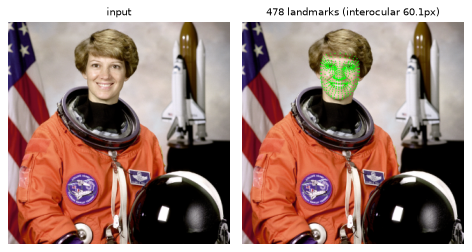

In [2]:
from carmine.landmarks import FaceLandmarker
from skimage import data

PORTRAIT = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)
LANDMARKER = FaceLandmarker()
LM = LANDMARKER.detect(PORTRAIT)

assert LM.shape == (478, 2), LM.shape

from carmine.geometry import interocular_distance

IOD = interocular_distance(LM)

dots = PORTRAIT.copy()
for x, y in LM:
    cv2.circle(dots, (int(round(x)), int(round(y))), 1, (0, 255, 0), -1)

show([PORTRAIT, dots], ["input", f"478 landmarks (interocular {IOD:.1f}px)"])

### Masks: soft, and scaled to the face

Seven masks, every dimension a fraction of the interocular distance. The lip
mask subtracts the inner mouth contour, so colour never lands on teeth no
matter how open the mouth is. The eyeshadow mask carries a crease gradient —
full strength at the lash line, fading to 0.35 toward the brow — because real
eyeshadow is not applied uniformly. The blush ellipse is multiplied by a
feathered face oval so its soft edge cannot spill onto hair or background.

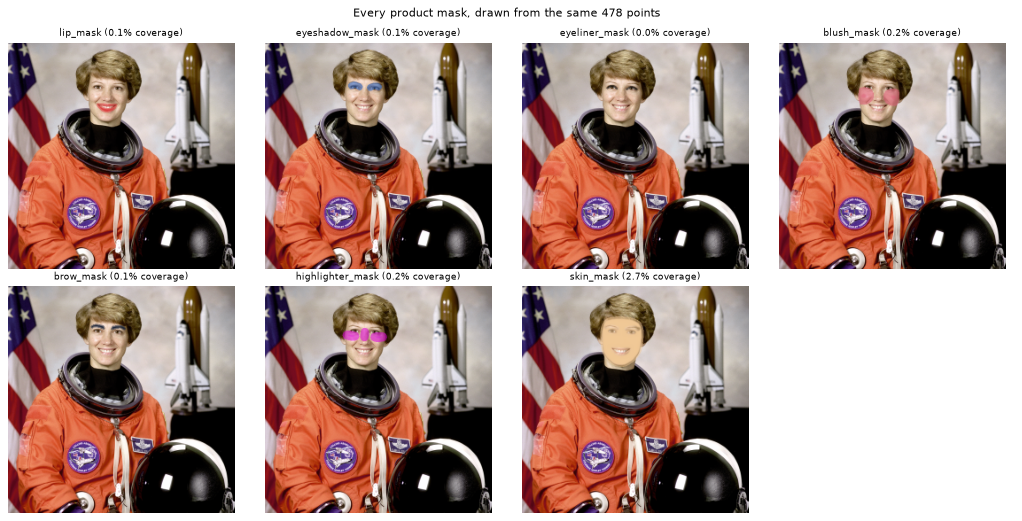

In [3]:
from carmine import masks

MASK_FNS = [
    ("lip_mask", (60, 60, 220)),
    ("eyeshadow_mask", (200, 100, 40)),
    ("eyeliner_mask", (20, 20, 20)),
    ("blush_mask", (120, 90, 220)),
    ("brow_mask", (60, 40, 30)),
    ("highlighter_mask", (220, 0, 220)),
    ("skin_mask", (150, 200, 240)),
]

shape = PORTRAIT.shape[:2]
tiles, titles = [], []
for name, colour in MASK_FNS:
    mask = getattr(masks, name)(LM, shape)
    assert mask.shape == shape and mask.dtype == np.float32
    assert mask.min() >= 0.0 and mask.max() <= 1.0, name
    alpha = np.where(mask > 0.02, np.maximum(mask, 0.55), mask)[:, :, None]
    blend = PORTRAIT.astype(np.float32) * (1 - alpha) + np.array(colour, np.float32) * alpha
    tiles.append(blend.astype(np.uint8))
    titles.append(f"{name} ({mask.mean() * 100:.1f}% coverage)")

fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
for ax, tile, title in zip(axes.flat, tiles, titles):
    ax.imshow(cv2.cvtColor(cv2.resize(tile, (256, 256)), cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8.5)
    ax.axis("off")
axes.flat[-1].axis("off")
fig.suptitle("Every product mask, drawn from the same 478 points", fontsize=10)
fig.tight_layout()
plt.show()

### Pigment: the four preset looks

Products are composited in a fixed order — smoothing, blush, highlighter,
eyeshadow, brows, lipstick, eyeliner — chosen so higher-contrast products
layer over softer ones rather than being dimmed by them. Eyeliner is the one
deliberate exception to texture preservation: it is a flat opaque paint,
because covering what is underneath is the entire job of eyeliner.

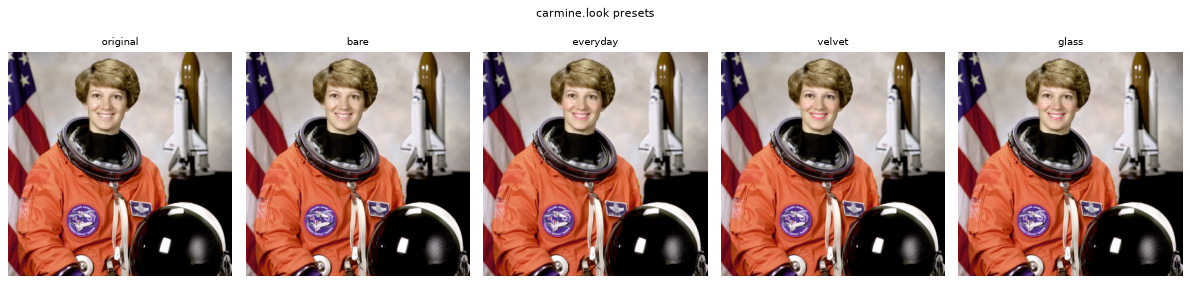

In [4]:
from carmine.engine import apply_look
from carmine.look import PRESETS

names = ["bare", "everyday", "velvet", "glass"]
renders = [apply_look(PORTRAIT, PRESETS[n], landmarks=LM) for n in names]

for name, out in zip(names, renders):
    assert out.shape == PORTRAIT.shape and out.dtype == np.uint8
    assert not np.array_equal(out, PORTRAIT), name

show([PORTRAIT] + renders, ["original"] + names, suptitle="carmine.look presets")

## Why chroma tinting in CIELAB, and not a fill

The obvious way to paint a lip is to fill the polygon with the shade and
alpha-blend it over the photo. It is one line of OpenCV, and it is what the
`opaque_fill` baseline in `carmine.baselines` does — faithfully, not as a
straw man, because it is a failure mode that ships in real AR filters.

The problem is that the lip's own structure — the vertical striations, the
specular highlight on the lower lip, the shadow at the corners — lives almost
entirely in *lightness*. A fill overwrites lightness with the shade's, so all
of that goes. Carmine converts to CIELAB and moves only the chroma channels
(a, b) toward the target, pulling lightness (L) at most a capped fraction of
the way: 0.30 for matte lipstick, 0.35 otherwise, 0.15 for blush, 0.10 for
highlighter.

Here is the same lip region, same look, both paths.

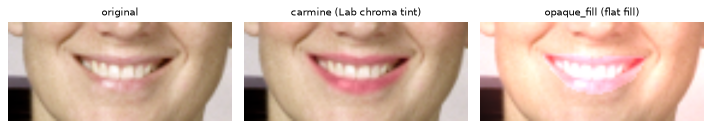

method (this portrait)  texture kept  detail ratio  |ΔL| lip
----------------------  ------------  ------------  --------
carmine                        0.969         0.802      22.6
opaque_fill                    0.966         0.708      47.2

lip |ΔL| on this portrait: carmine 22.6 vs opaque_fill 47.2


In [5]:
from carmine import baselines, metrics, regions
from benchmark import benchmark_look

# The exact configuration the published benchmark scored every method under:
# velvet, lipstick finish forced to satin, smoothing forced to 0.
LOOK = benchmark_look()
assert LOOK.lipstick.finish == META["finish_override"] == "satin"
assert LOOK.smoothing == META["smoothing_override"] == 0.0

CARMINE_OUT = apply_look(PORTRAIT, LOOK, landmarks=LM)
FILL_OUT = baselines.opaque_fill(PORTRAIT, LM, LOOK)

lip = masks.lip_mask(LM, shape)
pts = LM[regions.LIPS_OUTER]
(x0, y0), (x1, y1) = pts.min(axis=0), pts.max(axis=0)
px, py = (x1 - x0) * 0.6, (y1 - y0) * 0.8
box = (
    slice(int(max(0, y0 - py)), int(min(shape[0], y1 + py))),
    slice(int(max(0, x0 - px)), int(min(shape[1], x1 + px))),
)

crops = [PORTRAIT[box], CARMINE_OUT[box], FILL_OUT[box]]
show(crops, ["original", "carmine (Lab chroma tint)", "opaque_fill (flat fill)"], height=260)

rows = []
for label, out in (("carmine", CARMINE_OUT), ("opaque_fill", FILL_OUT)):
    rows.append([
        label,
        f"{metrics.lip_texture_kept(PORTRAIT, out, lip):.3f}",
        f"{metrics.lip_detail_retention(PORTRAIT, out, lip):.3f}",
        f"{metrics.lip_luminance_shift(PORTRAIT, out, lip):.1f}",
    ])
table(["method (this portrait)", "texture kept", "detail ratio", "|ΔL| lip"], rows)

shift_carmine = metrics.lip_luminance_shift(PORTRAIT, CARMINE_OUT, lip)
shift_fill = metrics.lip_luminance_shift(PORTRAIT, FILL_OUT, lip)
# The signature of a fill is a large mean-lightness move. That direction is
# what the 26-image benchmark measures too (13.2 vs 45.7 Lab-L units); this
# single portrait is an illustration of it, not a second measurement of it.
assert shift_fill > 2 * shift_carmine, (shift_carmine, shift_fill)
print(f"\nlip |ΔL| on this portrait: carmine {shift_carmine:.1f} vs opaque_fill {shift_fill:.1f}")

## Designing the metrics — including the one that was thrown out

The tempting protocol is: take a paired photo set (same face, with and
without makeup), run the engine on the bare photo, and score the output
against the with-makeup photo with SSIM. It gives one number, it looks
objective, and it is wrong.

It is wrong because the reference photo is *a* makeup application, not *the*
correct one. A different shade, a different lip line, a different amount of
product — all correct results, all penalised. And because SSIM is computed on
grayscale, it is blind to the one thing makeup is mostly about: colour.

That last part is cheap to demonstrate, so here it is on this portrait
instead of as an assertion. Treat one engine render as the "reference photo"
and score four candidates against it with grayscale SSIM.

candidate scored against the 'reference'  grayscale SSIM
----------------------------------------  --------------
same engine, a different shade                    0.9998
no makeup at all (the input)                      0.9995
flat opaque fill                                  0.9929
channel-swapped: a blue face                      0.9773


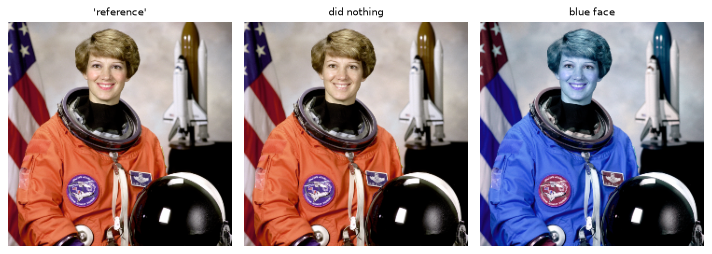


SSIM spread across all four candidates: 0.0226


In [6]:
import dataclasses

from skimage.metrics import structural_similarity

REFERENCE = CARMINE_OUT  # stand-in for a "ground truth with-makeup photo"

other_shade = apply_look(
    PORTRAIT,
    dataclasses.replace(LOOK, lipstick=dataclasses.replace(LOOK.lipstick, color="#C4707F")),
    landmarks=LM,
)
blue_face = REFERENCE[:, :, ::-1].copy()  # channel-swapped: a bright blue face

gray = lambda img: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
candidates = [
    ("same engine, a different shade", other_shade),
    ("no makeup at all (the input)", PORTRAIT),
    ("flat opaque fill", FILL_OUT),
    ("channel-swapped: a blue face", blue_face),
]
scores = {label: structural_similarity(gray(REFERENCE), gray(img)) for label, img in candidates}
table(
    ["candidate scored against the 'reference'", "grayscale SSIM"],
    [[label, f"{score:.4f}"] for label, score in scores.items()],
)
show([REFERENCE, PORTRAIT, blue_face], ["'reference'", "did nothing", "blue face"], height=240)

# Two failures, both fatal to the protocol:
#   1. every candidate lands in a 3%-wide band, so the metric has no dynamic
#      range in which to express "good" versus "wrong";
#   2. inside that band the ranking is actively perverse -- doing nothing at
#      all outscores a real (if crude) makeup application.
assert min(scores.values()) > 0.97, scores
assert scores["no makeup at all (the input)"] > scores["flat opaque fill"], scores
print("\nSSIM spread across all four candidates: "
      f"{max(scores.values()) - min(scores.values()):.4f}")

Doing nothing scores 0.9995. A face painted bright blue scores 0.9773. The
entire range between "perfect" and "catastrophic" is three parts in a
thousand, and within it the metric prefers inaction to effort. Any threshold
drawn on that axis would be arbitrary, and reference-SSIM was dropped as a
scoring protocol.

What replaced it is a set of narrow metrics that each answer one falsifiable
question about the *edit*, comparing before and after rather than against
somebody else's makeup:

| metric | question | direction |
| --- | --- | --- |
| `pigment_on_target` | what share of the pixel change landed inside the product regions? | higher |
| `background_untouched` | what share of off-face pixels are bit-identical? | higher |
| `lip_texture_kept` | does lip lightness still correlate with the original? | higher |
| `lip_detail_retention` | is the lip's high-frequency detail still there? | diagnostic |
| `lip_luminance_shift` | how far did mean lip brightness move? | lower |
| `identity_ssim` | is it still recognisably the same photograph? | higher |
| `ms_per_image` | what did it cost? | lower |

`identity_ssim` survives, but note what it is doing: it compares the output
to *its own input*, which is a question with one right answer, rather than to
a reference someone else painted.

## The photo benchmark

Protocol, in full:

* **26 photographs**, the no-makeup half of a local paired-portrait set. The
  photos are of private individuals and are not committed; the numbers are.
* **Four baselines**, each a standard failure mode of AR makeup filters,
  implemented faithfully in `carmine.baselines`: `mismatched_indices` (a
  68-point region table applied to a 478-point mesh), `opaque_fill` (correct
  regions, hard fill, additive composite), `channel_swap` (everything right
  until one RGB/BGR conversion at the very end), `untrained_gan` (a
  three-layer convnet at initialisation — no training loop exists anywhere in
  that module, so its output is structured noise by construction).
* **One look for everyone**: velvet, with two documented overrides — lipstick
  finish forced to satin (a matte finish damps micro-highlights *on purpose*,
  which would make the texture metrics measure an artistic choice), and skin
  smoothing forced to 0 (only Carmine has it, and it legitimately edits the
  whole face, which would make containment an unfair comparison).

In [7]:
METRIC_COLUMNS = [
    ("pigment_on_target", "on-target", "{:.3f}"),
    ("background_untouched", "bg intact", "{:.3f}"),
    ("lip_texture_kept", "texture", "{:.3f}"),
    ("lip_detail_retention", "detail", "{:.3f}"),
    ("lip_luminance_shift", "|ΔL| lip", "{:.1f}"),
    ("identity_ssim", "identity", "{:.3f}"),
    ("ms_per_image", "ms/img", "{:.1f}"),
]
ORDER = ["mismatched_indices", "opaque_fill", "channel_swap", "untrained_gan", "carmine"]

table(
    ["method"] + [label for _, label, _ in METRIC_COLUMNS],
    [[m] + [fmt.format(PHOTO[m][key]) for key, _, fmt in METRIC_COLUMNS] for m in ORDER],
)
print(f"\n{META['n_images']} photos; look={META['look_preset']}, "
      f"finish={META['finish_override']}, smoothing={META['smoothing_override']}")

# Narrated in the prose below -- pinned here so the two cannot drift.
c = PHOTO["carmine"]
close(c["pigment_on_target"], 0.838, 0.001)
close(c["background_untouched"], 1.0, 1e-9)
close(c["lip_texture_kept"], 0.988, 0.001)
close(c["lip_detail_retention"], 0.754, 0.001)
close(c["lip_luminance_shift"], 13.17, 0.01)
close(c["identity_ssim"], 0.998, 0.001)
close(PHOTO["opaque_fill"]["pigment_on_target"], 0.998, 0.001)
close(PHOTO["channel_swap"]["background_untouched"], 0.017, 0.001)
close(PHOTO["untrained_gan"]["identity_ssim"], 0.587, 0.001)
assert META["n_images"] == 26

method              on-target  bg intact  texture  detail  |ΔL| lip  identity  ms/img
------------------  ---------  ---------  -------  ------  --------  --------  ------
mismatched_indices      0.369      1.000    0.820   1.360       3.8     0.980     5.2
opaque_fill             0.998      1.000    0.987   0.952      45.7     0.996    11.2
channel_swap            0.144      0.017    0.976   0.801      31.3     0.993   226.5
untrained_gan           0.087      0.000   -0.230   0.368      87.5     0.587    38.1
carmine                 0.838      1.000    0.988   0.754      13.2     0.998   234.5

26 photos; look=velvet, finish=satin, smoothing=0.0


### Reading that table honestly

**Carmine wins containment and identity**, and the wins are not close:
83.8% of its edit energy lands inside the product regions with the background
bit-identical (1.000), against `channel_swap`'s 0.017 background score — that
baseline rewrites every pixel in the frame — and `untrained_gan`'s 0.587
identity SSIM, which is what "structured noise" scores.

**Three caveats that the table cannot show, and that matter more than the
wins:**

1. `pigment_on_target` is **opacity-blind and adversarial to feathering by
   construction**. It is a strict membership test at mask value > 0.05, not a
   soft weighting, so a feathered tint spreads change into low-mask pixels
   that the cutoff then counts against it. Carmine's 0.838 is a soft edge
   being penalised by a hard threshold, and that is the intended reading.
2. **`opaque_fill` shares its region geometry with the scorer.** Its 0.998 is
   evidence that its indices are correct, not that its blend is good. This
   metric structurally cannot distinguish a hard fill from a soft tint once
   the geometry is right — which is exactly why `lip_luminance_shift` exists.
3. **`lip_detail_retention` is a diagnostic, not a ranking.** Carmine scores
   0.754, below `opaque_fill`'s 0.952 and far below `mismatched_indices`'
   1.360. Both of those numbers are artefacts: `mismatched_indices` paints
   the wrong region entirely, so the true lip region it is scored on is left
   nearly untouched; an additive fill preserves relative variation right up
   to saturation. Carmine's own figure is depressed by design — its tint
   pulls lip lightness a capped fraction toward the target, which
   mechanically scales down high-frequency L variance by about that same
   fraction. It is not expected to reach 1.0 for an honest tint, and it is
   published as measured.

**Cost**: 234 ms per image, the slowest method in the table. That is the
Python reference path — full-resolution masks, true Gaussian feathers,
optimised for being verifiable rather than fast. The browser path is the one
that has to hit frame rate, and it is measured separately below.

### The opacity story: where the fill actually fails

`pigment_on_target` and `lip_texture_kept` both give `opaque_fill` a near
perfect score. Two metrics agreeing on a wrong answer is a good reason to
distrust both, and it is why a third was added: mean lightness shift inside
the lip region. A texture-preserving tint has a mechanism holding lightness
near the original — the `lightness_pull` cap. Additive compositing has none.

In [8]:
rows = []
for m in ORDER:
    rows.append([m, f"{PHOTO[m]['lip_luminance_shift']:.1f}",
                 f"{PHOTO[m]['spread']['lip_luminance_shift'][0]:.1f}"
                 f" – {PHOTO[m]['spread']['lip_luminance_shift'][1]:.1f}"])
table(["method", "|ΔL| lip", "min – max over 26"], rows)

fill_shift = close(PHOTO["opaque_fill"]["lip_luminance_shift"], 45.7, 0.05)
carmine_shift = close(PHOTO["carmine"]["lip_luminance_shift"], 13.2, 0.05)
print(f"\nthe fill moves mean lip lightness {fill_shift / carmine_shift:.1f}x further "
      "than the tint, on a 0-100 scale")

method              |ΔL| lip  min – max over 26
------------------  --------  -----------------
mismatched_indices       3.8          0.3 – 7.3
opaque_fill             45.7        27.7 – 64.6
channel_swap            31.3        19.6 – 41.0
untrained_gan           87.5       47.2 – 142.4
carmine                 13.2         0.6 – 23.1

the fill moves mean lip lightness 3.5x further than the tint, on a 0-100 scale


45.7 against 13.2 Lab-L units — the fill moves mean lip brightness three and
a half times further, and half the 0–100 lightness scale is a lip that no
longer matches the face it is on. This is the number that catches what the
containment and correlation metrics structurally cannot, and it is why the
figure `reports/figures/opacity_compare.png` exists next to it: the failure
is visible at the pixel level too.

## Video stability: a null result, published as one

Landmark detectors jitter frame to frame. The standard answer is a One-Euro
filter on the landmark stream, and Carmine has one (`carmine.filters`). The
question is whether it should be on by default.

The protocol: a 90-frame synthetic clip built from one still with a known
affine motion path (pan, zoom, rotation, plus sensor noise), so ground-truth
landmark positions are known and *tracking lag* can be separated from
*jitter*. A filter is only allowed to count as a win if it (a) cuts
motion-compensated jitter by more than 20% and (b) does not inflate deviation
from ground truth by more than 1.5x. Twelve (min_cutoff, beta) pairs were
swept.

In [9]:
best = STABILITY["one_euro_best_tuned"]
shipped = STABILITY["one_euro_shipped_defaults"]
raw = STABILITY["raw"]
grid = STABILITY["grid_search"]

table(
    ["stream", "deviation px/iod", "jitter px/iod", "meets deviation cap"],
    [
        ["raw (no filter)", f"{raw['deviation_px_iod']:.4f}", f"{raw['jitter_px_iod']:.5f}", "—"],
        ["one-euro, best tuned", f"{best['deviation_px_iod']:.4f}",
         f"{best['jitter_px_iod']:.5f}", str(best["meets_deviation_constraint"])],
        ["one-euro, shipped defaults", f"{shipped['deviation_px_iod']:.4f}",
         f"{shipped['jitter_px_iod']:.5f}", "False"],
    ],
)

reduction = close(STABILITY["jitter_reduction_pct"], 7.556, 0.01)
threshold = grid["improvement_threshold_pct"]
print(f"\nbest tuned config: min_cutoff={best['min_cutoff']}, beta={best['beta']}")
print(f"jitter reduction {reduction:.1f}% against a {threshold:.0f}% bar -> "
      f"selected_params={STABILITY['selected_params']}")
print(f"shipped defaults: deviation {shipped['deviation_ratio_vs_raw']:.2f}x raw, "
      f"jitter {shipped['jitter_change_pct_vs_raw']:+.1f}% vs raw")

assert STABILITY["meets_improvement_threshold"] is False
assert STABILITY["selected_params"] is None
assert reduction < threshold
close(shipped["deviation_ratio_vs_raw"], 4.60, 0.01)
close(shipped["jitter_change_pct_vs_raw"], 73.3, 0.05)
assert len(grid["results"]) == 12

stream                      deviation px/iod  jitter px/iod  meets deviation cap
--------------------------  ----------------  -------------  -------------------
raw (no filter)                       0.0113        0.00246                    —
one-euro, best tuned                  0.0155        0.00227                 True
one-euro, shipped defaults            0.0520        0.00426                False

best tuned config: min_cutoff=1.5, beta=0.5
jitter reduction 7.6% against a 20% bar -> selected_params=None
shipped defaults: deviation 4.60x raw, jitter +73.3% vs raw


**The filter did not earn its place, so it did not get one.** The best
constraint-satisfying configuration cut jitter by 7.6% against a 20% bar. The
defaults the filter actually ships with are worse than doing nothing on this
clip: 4.6x the deviation from ground truth and 73% *more* jitter, because a
low beta on a nearly-still, low-noise stream lags the motion it is supposed
to be tracking.

`VideoEngine` still constructs the filter (it is the right tool for a
genuinely jittery camera, and `--no-smooth-landmarks` turns it off), but no
default was changed on the strength of a measurement that did not support
one. One caveat on the absolute numbers: ground truth is anchored to a real
frame-0 detection rather than a synthetic exact position, so frame 0's own
error is not counted against anyone and the deviations are mildly optimistic.
The raw-vs-filtered comparison is unaffected — every stream shares that
anchor.

## Parity: are the two surfaces the same engine?

Two implementations of one algorithm is two chances to be wrong. The claim
being tested is that the browser produces the Python engine's output, and it
is tested against committed reference renders in CIELAB ΔE — three frames ×
three looks, in a real browser, driven headlessly by `scripts/verify_site.py`.

There are two tables because there are two questions, and only publishing the
first would be misleading.

In [10]:
parity = BROWSER["parity"]


def worst(cases):
    return {
        "mean": max(c["meanDeltaE"] for c in cases),
        "p99": max(c["p99DeltaE"] for c in cases),
        "max": max(c["maxDeltaE"] for c in cases),
        "outside": max(c["changedOutsideSupport"] for c in cases),
    }


cpu, e2e = worst(parity["cpu"]), worst(parity["endToEnd"])
table(
    ["comparison (worst of 9 cases)", "mean ΔE", "p99 ΔE", "max ΔE", "outside"],
    [
        ["same landmarks, both engines", f"{cpu['mean']:.3f}", f"{cpu['p99']:.3f}",
         f"{cpu['max']:.3f}", cpu["outside"]],
        ["end-to-end, each its own landmarker", f"{e2e['mean']:.3f}", f"{e2e['p99']:.3f}",
         f"{e2e['max']:.3f}", e2e["outside"]],
    ],
)
print("\ngates enforced by the browser selftest: mean < 2.0, p99 < 5.0, max < 12.0, outside = 0")

close(cpu["mean"], 0.747, 0.001)
close(cpu["p99"], 2.763, 0.001)
close(cpu["max"], 11.434, 0.001)
close(e2e["mean"], 2.717, 0.001)
close(e2e["p99"], 18.454, 0.001)
close(e2e["max"], 30.135, 0.001)
assert cpu["outside"] == e2e["outside"] == 0
assert len(parity["cpu"]) == len(parity["endToEnd"]) == 9

comparison (worst of 9 cases)        mean ΔE  p99 ΔE  max ΔE  outside
-----------------------------------  -------  ------  ------  -------
same landmarks, both engines           0.747   2.763  11.434        0
end-to-end, each its own landmarker    2.717  18.454  30.135        0

gates enforced by the browser selftest: mean < 2.0, p99 < 5.0, max < 12.0, outside = 0


**Row one is the rendering claim.** Given the same landmarks, the two
engines agree to a worst-case mean ΔE of 0.747 over nine full-frame
comparisons, and not one pixel changed outside the region either engine
painted. A ΔE of 1 is roughly the threshold of a just-noticeable colour
difference, so the average disagreement is below what an eye can see. The
worst single pixel is 11.434, and it is understood rather than mysterious:
23 pixels out of 388,800 exceed ΔE 6, every one on the boundary of the
eyeliner stroke, where a two-pixel-wide line under a soft feather leaves a
one-pixel rasterisation disagreement nothing to hide behind.

**Row two is the honest one.** Let each side run its own landmark detector —
Python's MediaPipe build against the browser's wasm build — and the worst
mean rises to 2.717, p99 to 18.454. Nothing about the rendering changed. The
gap is the two detectors placing the same face a fraction of a pixel apart,
and it is roughly seven times larger than the entire rendering disagreement.

That is the useful finding, and it points at where effort belongs: the
pigment maths is not the risk on this pipeline. The landmarker is.

## Timing: what a live frame costs

A frame-rate claim is worth nothing without the hardware, the resolution and
the face size attached, so all three are here. The measurement is 120 frames
at 1280×720 after 10 warm-up frames, medians rather than means (a mean folds
shader compilation and one stray garbage collection into the headline), with
the GPU draw fenced by `gl.finish()` so it measures the frame rather than the
speed of talking to the driver.

The face is deliberately close to the camera: interocular distance ≈ 199px at
processing resolution. Mask cost scales with that number, not with the
frame's, so this is the expensive case rather than a flattering one.

In [11]:
hw = BROWSER["timing_hardware"]
assert hw["recorded"] is True
t = hw["timing"]
live = t["livePath"]

table(
    ["stage", "median ms", "min", "max"],
    [
        ["detect (wasm landmarker)", f"{t['detect']['median']:.1f}",
         f"{t['detect']['min']:.1f}", f"{t['detect']['max']:.1f}"],
        ["masks, live path", f"{live['buildMasks']['median']:.1f}",
         f"{live['buildMasks']['min']:.1f}", f"{live['buildMasks']['max']:.1f}"],
        ["draw, fenced", f"{live['draw']['median']:.1f}",
         f"{live['draw']['min']:.1f}", f"{live['draw']['max']:.1f}"],
        ["total, live path", f"{live['totalMedian']:.1f}", "", ""],
        ["masks, exact path (reference)", f"{t['buildMasks']['median']:.1f}",
         f"{t['buildMasks']['min']:.1f}", f"{t['buildMasks']['max']:.1f}"],
    ],
)

fps = 1000.0 / live["totalMedian"]
print(f"\n{t['width']}x{t['height']}, {t['frames']} frames, look={t['look']}, "
      f"interocular {t['interocularPx']:.0f}px")
print(f"renderer: {hw['glRenderer']}")
print(f"live path: {live['totalMedian']:.1f} ms/frame -> {fps:.1f} fps")
print(f"mask stage: {t['buildMasks']['median']:.1f} ms exact -> "
      f"{live['buildMasks']['median']:.1f} ms live "
      f"({t['buildMasks']['median'] / live['buildMasks']['median']:.0f}x)")
print(f"detect is {t['detect']['median'] / live['totalMedian'] * 100:.0f}% of the live frame")

close(live["totalMedian"], 26.6, 0.05)
close(fps, 37.6, 0.1)
close(t["detect"]["median"], 17.5, 0.05)
close(live["buildMasks"]["median"], 7.3, 0.05)
close(t["buildMasks"]["median"], 357.6, 0.1)
close(t["interocularPx"], 199, 1.0)
assert t["fenced"] is True

stage                          median ms    min    max
-----------------------------  ---------  -----  -----
detect (wasm landmarker)            17.5   12.2   24.6
masks, live path                     7.3    6.4   13.2
draw, fenced                         1.8    1.5    4.4
total, live path                    26.6              
masks, exact path (reference)      357.6  351.9  414.6

1280x720, 120 frames, look=velvet, interocular 199px
renderer: ANGLE (Apple, ANGLE Metal Renderer: Apple M1 Pro, Unspecified Version)
live path: 26.6 ms/frame -> 37.6 fps
mask stage: 357.6 ms exact -> 7.3 ms live (49x)
detect is 66% of the live frame


**26.6 ms per frame — about 37.6 fps** at 720p with a face filling the frame,
on an M1 Pro through Metal. Comfortably real-time, and the breakdown says
where the remaining time goes: landmark detection is 17.5 ms of it, roughly
two-thirds, while the entire GPU draw is 1.8 ms.

The mask stage is where the live path earns its name. Built the reference way
— full processing resolution, true Gaussian feathers — masks cost 357.6 ms
per frame, which is not a live path at all. The live path halves the
processing long side (quartering the pixel count) and swaps the Gaussians for
box approximations, giving 7.3 ms: a factor of about 49. That is an
approximation and it is labelled as one everywhere it appears, including in
the parity harness, which compares against the exact path so the shortcut can
never be quietly measured as if it were the reference.

The optimisation nobody needs: the shader. Every product composites in a
single fragment pass, so the colour maths is 7% of the frame. The detector is
the bottleneck, and it is somebody else's code.

## What did not work, and what this does not do

Published negatives, in one place:

* **Reference-SSIM scoring.** Tried, measured, thrown out. Doing nothing
  scores 0.9995 against a with-makeup reference; a bright blue face scores
  0.9773. No usable dynamic range and a perverse ranking inside it.
* **One-Euro smoothing as a default.** 7.6% jitter reduction against a 20%
  bar, and the filter's own shipped defaults are worse than no filter at all
  on a clean clip. Published as a null result; no default changed.
* **`lip_detail_retention` 0.754.** Carmine scores below two baselines on a
  metric it does not win. The number is mechanically explained by the
  lightness-pull cap, and it stays in the table at full size.
* **234 ms per image in Python.** The slowest method benchmarked. The
  reference path optimises for being checkable, not fast.

Known limits:

* **One face.** The landmarker is configured for a single subject; a group
  photo gets one made-up face.
* **Occlusion is not handled.** A hand across the mouth or a microphone in
  front of the lips gets lipstick painted over it — the masks come from
  landmark geometry, and geometry does not know what is in front of it.
* **The engine is not a shade-matching product.** It applies the colour it is
  given. It does not tell you which colour to want.
* **The synthetic stability clip is clean.** Its conclusion — that smoothing
  is an opt-in, not a free win — is a conclusion about clean streams. A
  genuinely noisy webcam is exactly where the filter that failed here would
  be expected to pay off.
* **26 photographs is a small set**, from one paired-portrait source. The
  gaps between methods here are large enough to survive that, but nothing in
  this table should be read as a population estimate.

Everything above is reproducible from the repository: `scripts/benchmark.py`
and `scripts/stability_bench.py` write `reports/benchmark.json`,
`scripts/verify_site.py --with-parity` writes `reports/browser_metrics.json`,
and this notebook reads both and refuses to execute if the prose has drifted
from them.